In [ ]:
import pandas as pd
import os

# --- 1. CONFIGURATION ---
# Define groups and their respective files
data_groups = [
    {'id': 'g1', 
     's1': '/home/ist-seminar/Documents/data/20251027/pose_20251027_g1_s1_meta_enc.csv', 
     's2': '/home/ist-seminar/Documents/data/20251027/pose_20251027_g1_s2_meta_enc.csv'},
    {'id': 'g2', 
     's1': '/home/ist-seminar/Documents/data/20251027/pose_20251027_g2_s1_meta_enc.csv', 
     's2': '/home/ist-seminar/Documents/data/20251027/pose_20251027_g2_s2_meta_enc.csv'},
    {'id': 'g3', 
     's1': '/home/ist-seminar/Documents/data/20251027/pose_20251027_g3_s1_meta_enc.csv', 
     's2': '/home/ist-seminar/Documents/data/20251027/pose_20251027_g3_s2_meta_enc.csv'}
]

# Output directory
output_dir = './data/'

# --- 2. PROCESSING ---
for group in data_groups:
    # Load S1 and S2
    df_s1 = pd.read_csv(group['s1'])
    df_s2 = pd.read_csv(group['s2'])
    
    # Merge on 'time' column with suffixes to distinguish participants
    df_merged = pd.merge(df_s1, df_s2, on='time', suffixes=('_s1', '_s2'))
    
    # Save the merged CSV
    out_name = f"pose_20251027_{group['id']}_merged.csv"
    df_merged.to_csv(os.path.join(output_dir, out_name), index=False)
    
    # Simple status check
    print(f"Group {group['id']} processed. Rows: {len(df_merged)}")

In [ ]:
import pympi
import numpy as np
from scipy.signal import find_peaks
import glob

all_samples = []
merged_files = glob.glob(os.path.join(output_dir, 'pose_20251027_g*_merged.csv'))

for csv_path in merged_files:
    df = pd.read_csv(csv_path)
    group_id = csv_path.split('_')[-2]
    
    # Bias correction: medians as neutral baseline
    medians = {c: df[c].median() for c in ['yaw_s1', 'yaw_s2', 'pitch_s1', 'pitch_s2']}
    
    # EAF file path
    eaf_path = f'/home/ist-seminar/Documents/data/annotation/meta-segment/20251027_{group_id}_all_meta_combined.eaf'
    eaf = pympi.Eaf(eaf_path)
    
    for start, end, label in eaf.get_annotation_data_for_tier('meta-topic'):
        dur = (end - start) / 1000
        df_slice = df[(df['time'] >= start/1000) & (df['time'] <= end/1000)]
        
        if len(df_slice) > 5:
            # Features
            y1 = np.abs(df_slice['yaw_s1'] - medians['yaw_s1']).mean()
            y2 = np.abs(df_slice['yaw_s2'] - medians['yaw_s2']).mean()
            p1 = len(find_peaks(df_slice['pitch_s1'], prominence=1.0, distance=5)[0]) / dur
            p2 = len(find_peaks(df_slice['pitch_s2'], prominence=1.0, distance=5)[0]) / dur
            
            all_samples.append({
                'total_gaze_dev': y1 + y2,
                'avg_nod_rate': (p1 + p2) / 2,
                'label': label.split('/')[-1].strip()
            })

pd.DataFrame(all_samples).to_csv('samples.csv', index=False)
print("Samples saved to samples.csv")

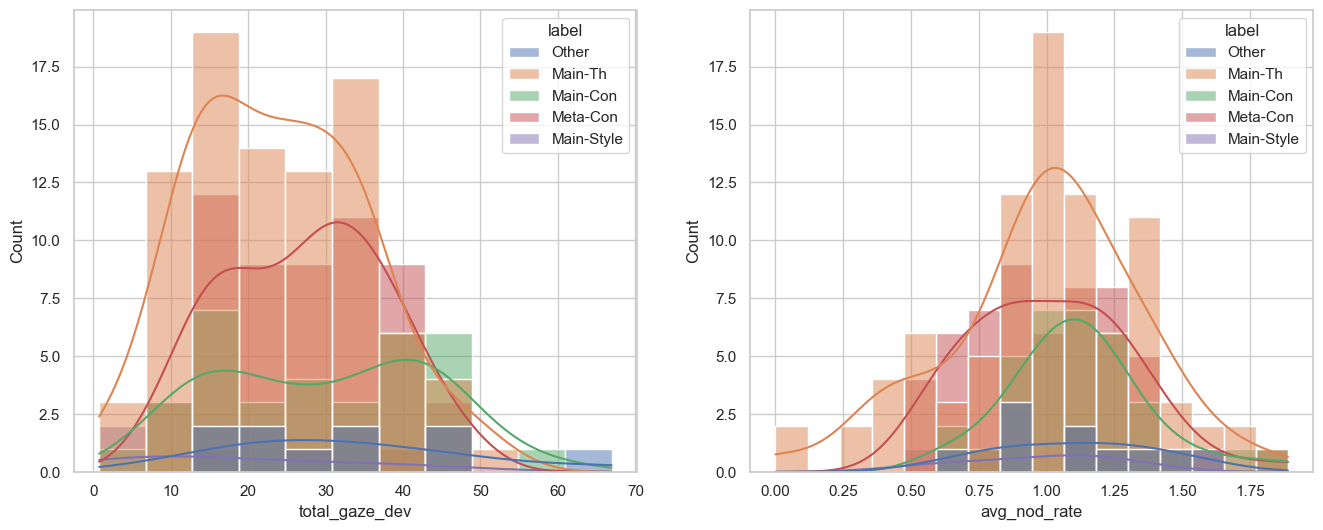

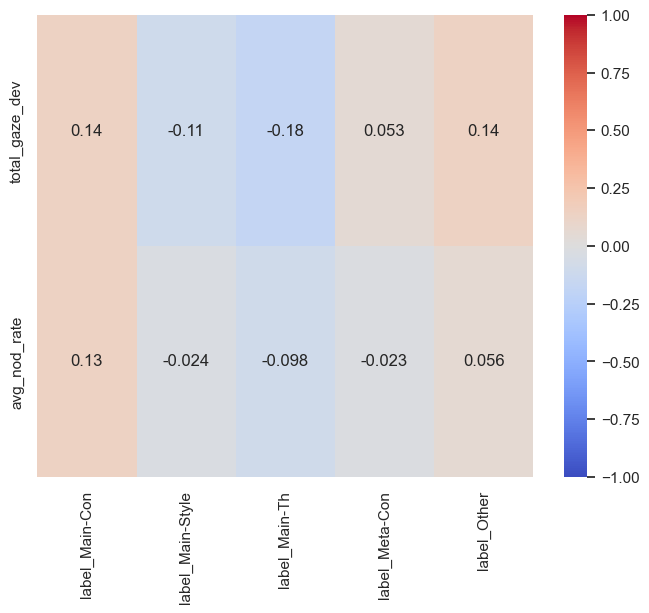

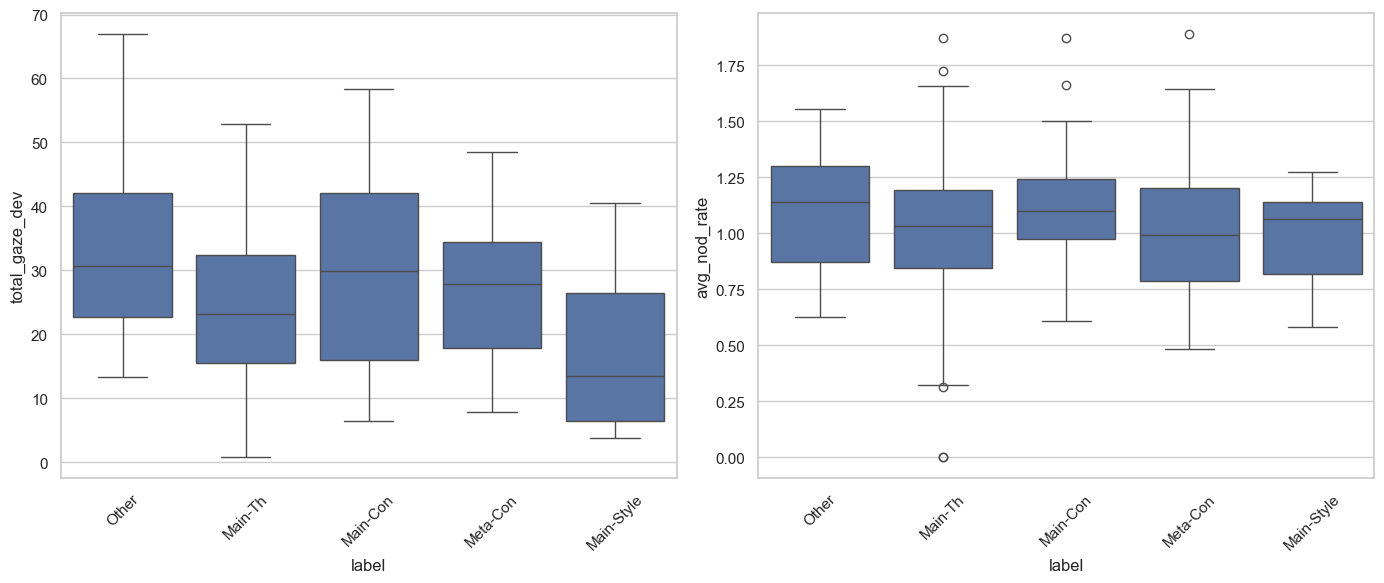

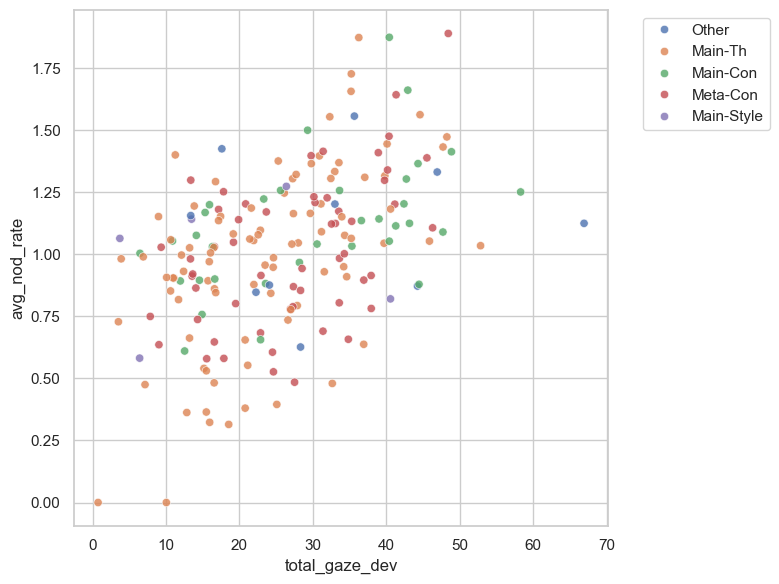

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv('samples.csv')
sns.set_theme(style="whitegrid")

# Histograms
plt.figure(figsize=(16, 6))
plt.subplot(1, 2, 1); sns.histplot(data=df, x='total_gaze_dev', hue='label', kde=True)
plt.subplot(1, 2, 2); sns.histplot(data=df, x='avg_nod_rate', hue='label', kde=True)
plt.show()

# Correlation Heatmap
df_dummies = pd.get_dummies(df, columns=['label'])
feature_cols = ['total_gaze_dev', 'avg_nod_rate']
label_cols = [c for c in df_dummies.columns if c.startswith('label_')]

corr = df_dummies[feature_cols + label_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr.loc[feature_cols, label_cols],
    annot=True,
    cmap='coolwarm',
    vmin=-1, vmax=1
)
plt.show()

# Boxplots
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
sns.boxplot(data=df, x='label', y='total_gaze_dev')
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='label', y='avg_nod_rate')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Scatterplot
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df,
    x='total_gaze_dev',
    y='avg_nod_rate',
    hue='label',
    palette='deep',
    alpha=0.8
)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

total_gaze_dev: Sum of mean absolute deviations of both speakers' head yaw angles from their individual baseline (median). Low values indicate stable head position (more attention to screen), high values indicate more head movement(e.g. mutual gaze).

avg_nod_rate: Average frequency of head pitch peaks detected for both participants, approximating nodding frequency.

other considered features: mutual_gaze_duration, mutual_gaze_count (this part of code is lost because of my mistake, but I have observed that visualization results are also not ideal)

It seems that features denoting gaze and nodding behavior are not sufficient to distinguish between the different labels, which is also demonstrated by the video, since I have observed that the mutual gaze and nodding patterns are quite similar across the Main-th, Main-con, and Meta-con conditions.